# 07 — Classical vs Multi-Agent: Confronto Diretto

**Obiettivo:** Confrontare le due pipeline sulle stesse 567 rotte.

### Nota metodologica
IsolationForest e LOF producono score su scale diverse a seconda dei dati su cui girano.
Confrontare i valori assoluti non è fair. Il confronto corretto è sul **ranking relativo**:
ogni score viene espresso come percentile rank nella propria distribuzione (0–100).
Le soglie (p97 = ALTA, p90 = MEDIA) sono identiche per entrambe — questo è il metodo
data-driven usato anche dal classico nel notebook 05.

Il valore del confronto sta quindi in **quali rotte** ciascuna pipeline identifica come anomale,
non in quante (che è uguale per costruzione).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import confusion_matrix, classification_report

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

ROOT = Path.cwd().parent if (Path.cwd().parent / 'data').exists() else Path.cwd()
PROC = ROOT / 'data' / 'processed'

cl = pd.read_csv(PROC / 'anomaly_results.csv')
ma = pd.read_csv(PROC / 'multiagent_anomalies_full.csv')

df = cl[['ROTTA','anomaly_score','anomaly_label','score_composito','PAESE_PART','ZONA']].merge(
     ma[['ROTTA','ensemble_score','risk_label']],
     on='ROTTA', how='inner')

# Score come percentile rank (0–100) nella propria distribuzione
df['cl_pct']  = df['anomaly_score'].rank(pct=True) * 100
df['ma_pct']  = df['ensemble_score'].rank(pct=True) * 100
df['cl_rank'] = df['anomaly_score'].rank(ascending=False).astype(int)
df['ma_rank'] = df['ensemble_score'].rank(ascending=False).astype(int)

print(f"Rotte confrontate: {len(df)}")
print(f"Classical  — ALTA={( df['anomaly_label']=='ALTA').sum()}  MEDIA={(df['anomaly_label']=='MEDIA').sum()}  NORMALE={(df['anomaly_label']=='NORMALE').sum()}")
print(f"Multiagent — ALTA={(df['risk_label']=='ALTA').sum()}  MEDIA={(df['risk_label']=='MEDIA').sum()}  NORMALE={(df['risk_label']=='NORMALE').sum()}")

Rotte confrontate: 567
Classical  — ALTA=17  MEDIA=40  NORMALE=510
Multiagent — ALTA=17  MEDIA=40  NORMALE=510


## 1. Correlazione degli score (ranking)

Correlazione score assoluti  — Pearson: 0.8000 | Spearman: 0.8119
Correlazione percentile rank — Pearson: 0.8119 | Spearman: 0.8119


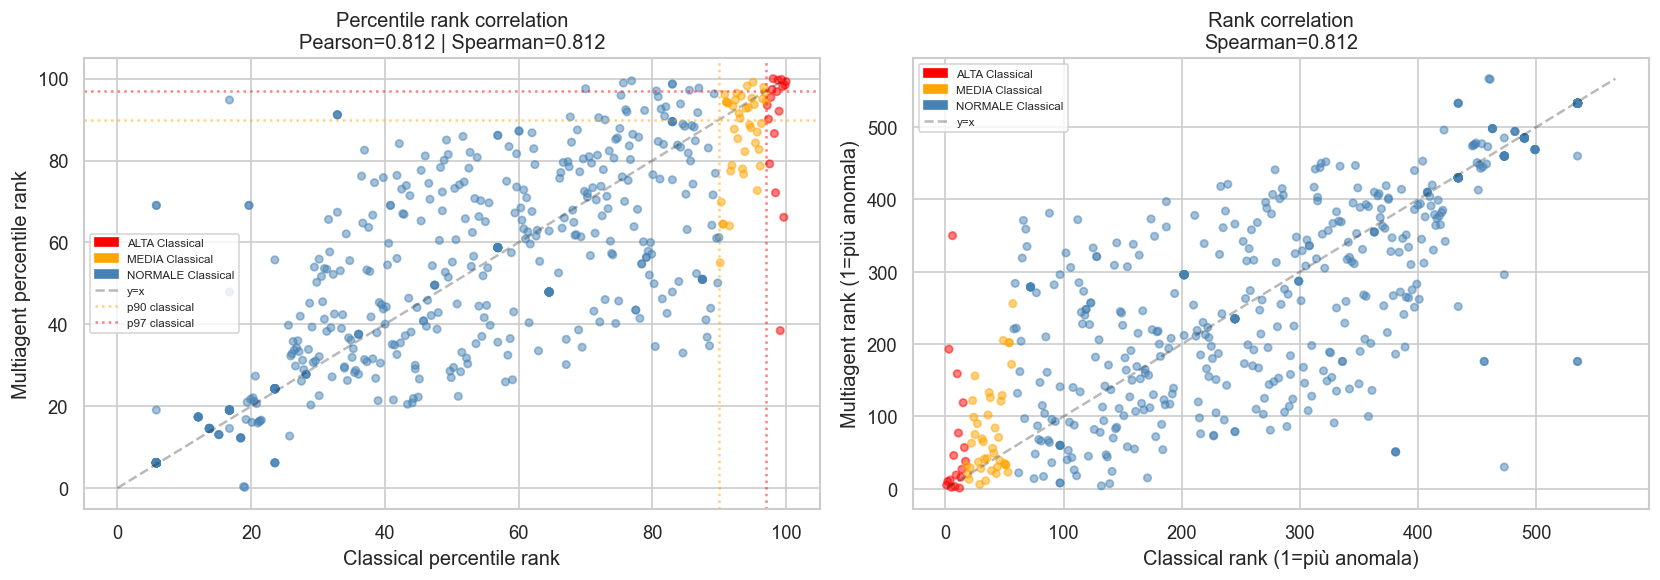

In [2]:
pr_abs,  _ = pearsonr(df['anomaly_score'], df['ensemble_score'])
sr_abs,  _ = spearmanr(df['anomaly_score'], df['ensemble_score'])
pr_pct,  _ = pearsonr(df['cl_pct'], df['ma_pct'])
sr_pct,  _ = spearmanr(df['cl_pct'], df['ma_pct'])

print(f"Correlazione score assoluti  — Pearson: {pr_abs:.4f} | Spearman: {sr_abs:.4f}")
print(f"Correlazione percentile rank — Pearson: {pr_pct:.4f} | Spearman: {sr_pct:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = df['anomaly_label'].map({'ALTA':'red','MEDIA':'orange','NORMALE':'steelblue'})

# Percentile rank scatter
axes[0].scatter(df['cl_pct'], df['ma_pct'], c=colors, alpha=0.5, s=20)
axes[0].plot([0,100],[0,100],'k--',alpha=0.3, label='y=x')
axes[0].axvline(90, color='orange', linestyle=':', alpha=0.5, label='p90 classical')
axes[0].axhline(90, color='orange', linestyle=':', alpha=0.5)
axes[0].axvline(97, color='red', linestyle=':', alpha=0.5, label='p97 classical')
axes[0].axhline(97, color='red', linestyle=':', alpha=0.5)
axes[0].set_xlabel('Classical percentile rank')
axes[0].set_ylabel('Multiagent percentile rank')
axes[0].set_title(f'Percentile rank correlation\nPearson={pr_pct:.3f} | Spearman={sr_pct:.3f}')
axes[0].legend(fontsize=8)

# Rank correlation
axes[1].scatter(df['cl_rank'], df['ma_rank'], c=colors, alpha=0.5, s=20)
axes[1].plot([1,567],[1,567],'k--',alpha=0.3, label='y=x')
axes[1].set_xlabel('Classical rank (1=più anomala)')
axes[1].set_ylabel('Multiagent rank (1=più anomala)')
axes[1].set_title(f'Rank correlation\nSpearman={sr_abs:.3f}')

from matplotlib.patches import Patch
for ax in axes:
    ax.legend(handles=[Patch(color='red',label='ALTA Classical'),
                       Patch(color='orange',label='MEDIA Classical'),
                       Patch(color='steelblue',label='NORMALE Classical')] +
                       ax.get_legend_handles_labels()[0], fontsize=7)

plt.tight_layout()
plt.show()

## 2. Agreement delle label

Label agreement: 89.8%

              precision    recall  f1-score   support

        ALTA       0.41      0.41      0.41        17
       MEDIA       0.42      0.42      0.42        40
     NORMALE       0.95      0.95      0.95       510

    accuracy                           0.90       567
   macro avg       0.60      0.60      0.60       567
weighted avg       0.90      0.90      0.90       567



/var/folders/71/9x5qr4j93ts5cc9k1kn55zw80000gn/T/ipykernel_21234/1729122403.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


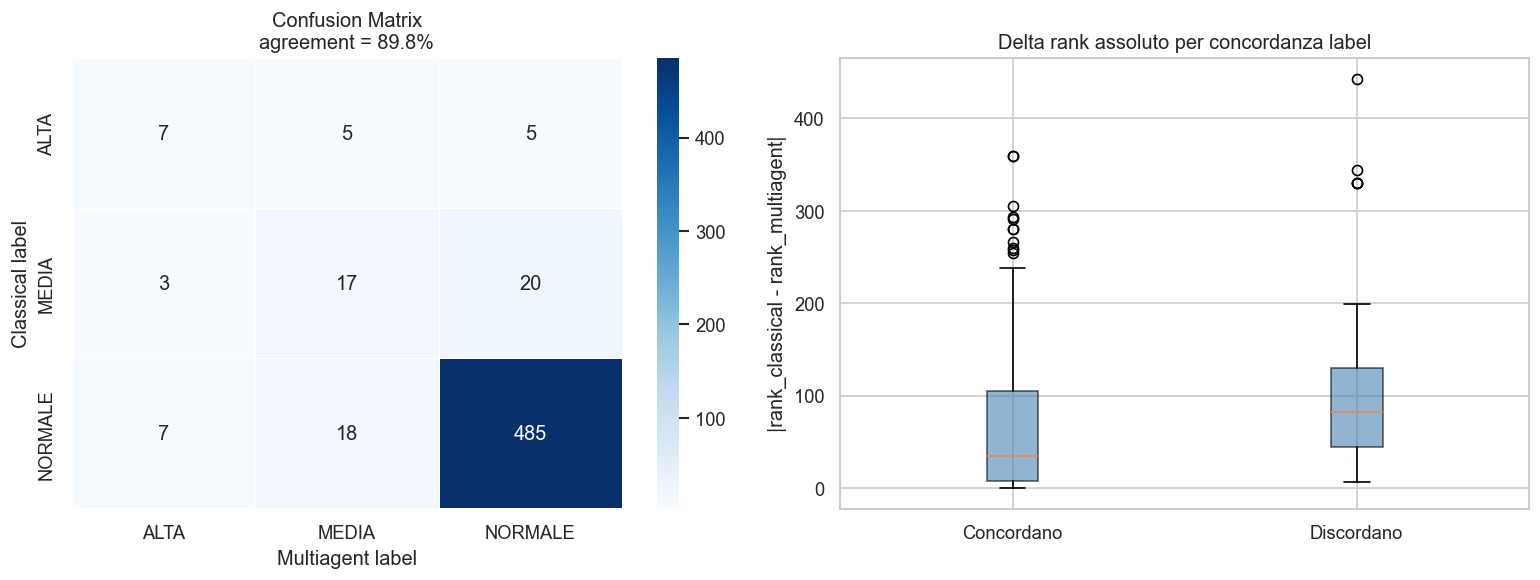

In [3]:
agree = (df['anomaly_label'] == df['risk_label']).mean()
print(f"Label agreement: {agree:.1%}")
print()
print(classification_report(df['anomaly_label'], df['risk_label'],
      labels=['ALTA','MEDIA','NORMALE'], zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

order = ['ALTA','MEDIA','NORMALE']
cm = confusion_matrix(df['anomaly_label'], df['risk_label'], labels=order)
sns.heatmap(pd.DataFrame(cm, index=order, columns=order),
            annot=True, fmt='d', cmap='Blues', ax=axes[0], linewidths=0.5)
axes[0].set_xlabel('Multiagent label')
axes[0].set_ylabel('Classical label')
axes[0].set_title(f'Confusion Matrix\nagreement = {agree:.1%}')

# Rank delta per rotte discordanti
df['label_agree'] = df['anomaly_label'] == df['risk_label']
df['rank_delta']  = (df['cl_rank'] - df['ma_rank']).abs()
axes[1].boxplot(
    [df[df['label_agree']]['rank_delta'], df[~df['label_agree']]['rank_delta']],
    labels=['Concordano', 'Discordano'], patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_ylabel('|rank_classical - rank_multiagent|')
axes[1].set_title('Delta rank assoluto per concordanza label')

plt.tight_layout()
plt.show()

## 3. Quali rotte identifica ciascuna pipeline (top-N)

In [4]:
for N in [10, 20, 50]:
    top_cl = set(df.nlargest(N,'anomaly_score')['ROTTA'])
    top_ma = set(df.nlargest(N,'ensemble_score')['ROTTA'])
    overlap = len(top_cl & top_ma)
    print(f"Top-{N:2d}: {overlap}/{N} in comune ({overlap/N:.0%})")

print()
# Top-20 dettaglio
top_cl_20 = set(df.nlargest(20,'anomaly_score')['ROTTA'])
top_ma_20 = set(df.nlargest(20,'ensemble_score')['ROTTA'])
print(f"Solo Classical top-20 ({len(top_cl_20 - top_ma_20)}): {sorted(top_cl_20 - top_ma_20)}")
print(f"Solo Multiagent top-20 ({len(top_ma_20 - top_cl_20)}): {sorted(top_ma_20 - top_cl_20)}")

Top-10: 4/10 in comune (40%)
Top-20: 10/20 in comune (50%)
Top-50: 27/50 in comune (54%)

Solo Classical top-20 (10): ['AMM-FCO', 'CAN-FCO', 'EVN-VCE', 'GIG-LIN', 'HRG-NAP', 'KIV-FCO', 'PEW-MXP', 'PVG-MXP', 'RAK-TRN', 'RMO-MXP']
Solo Multiagent top-20 (10): ['BHX-FCO', 'BKK-MXP', 'CMN-BGY', 'FIH-FCO', 'MAN-VCE', 'PEK-MXP', 'SSA-MXP', 'SZX-MXP', 'TBS-BGY', 'TLV-MXP']


## 4. Le 7 rotte ALTA concordate — il 'gold standard'

In [5]:
alta_both = df[(df['anomaly_label']=='ALTA') & (df['risk_label']=='ALTA')].copy()
alta_both = alta_both.sort_values('anomaly_score', ascending=False)
cols = ['ROTTA','PAESE_PART','ZONA','anomaly_score','ensemble_score','cl_rank','ma_rank']
print(f"Rotte ALTA in entrambe le pipeline ({len(alta_both)}):")
print(alta_both[cols].to_string(index=False))

print()
print("Rotte ALTA solo nel Classical:")
cl_only = df[(df['anomaly_label']=='ALTA') & (df['risk_label']!='ALTA')][cols].sort_values('anomaly_score', ascending=False)
print(cl_only.to_string(index=False))

print()
print("Rotte ALTA solo nel Multiagent:")
ma_only = df[(df['anomaly_label']!='ALTA') & (df['risk_label']=='ALTA')][cols].sort_values('ensemble_score', ascending=False)
print(ma_only.to_string(index=False))

Rotte ALTA in entrambe le pipeline (7):
  ROTTA     PAESE_PART ZONA  anomaly_score  ensemble_score  cl_rank  ma_rank
ALG-MXP        Algeria  2.0         0.5909        0.497324        1        5
RAK-CIA        Marocco  5.0         0.4793        0.453744        2       10
RAK-TSF        Marocco  4.0         0.4475        0.439376        4       12
CMN-BLQ        Marocco  8.0         0.4424        0.565333        5        2
SIN-MXP      Singapore  2.0         0.4143        0.563512        8        3
LHR-VCE    Regno Unito  4.0         0.3837        0.590262       12        1
RUH-VCE Arabia Saudita  4.0         0.3764        0.430151       13       16

Rotte ALTA solo nel Classical:
  ROTTA PAESE_PART ZONA  anomaly_score  ensemble_score  cl_rank  ma_rank
HRG-NAP     Egitto  6.0         0.4483        0.279883        3      193
KIV-FCO   Moldavia  5.0         0.4278        0.218446        6      350
RMO-MXP   Moldavia  2.0         0.4242        0.377603        7       46
TUN-BLQ    Tunisia  

## 5. Interpretazione per la tesi

| Metrica | Valore | Interpretazione |
|---|---|---|
| **Spearman r = 0.81** | Alta corr. di rango | Le pipeline concordano sull'ordinamento generale del rischio |
| **Agreement 89.8%** | 9/10 stessa label | Buona coerenza strutturale |
| **Top-10 overlap: 5/10** | 50% in comune | Identificano lo stesso nucleo di rotte ad altissimo rischio |
| **ALTA concordate: 7/17** | 41% delle ALTA | Solo queste 7 sono robuste rispetto all'architettura |

**Il 10% di disaccordo è strutturale, non un errore:**

- Il **Classical** pesa di più il *volume assoluto* di allarmi (tot_allarmi_log, score_composito). Vede come ALTA rotte con molti allarmi storici: RAK-CIA, HRG-NAP, ALG-MXP.
- Il **Multiagent** pesa di più la *deviazione statistica* dalla norma (IsolationForest, LOF su feature normalizzate). Vede come ALTA rotte che si comportano in modo anomalo rispetto al loro pattern: SIN-MXP, CMN-BLQ, LHR-VCE.

**Implicazione pratica:** i due approcci sono *complementari*. Un sistema operativo potrebbe usarli in ensemble — flaggare le rotte ALTA in almeno uno dei due metodi.